<a href="https://colab.research.google.com/github/j-yxn/Google-Search-Analysis/blob/main/Google_Search_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Trends Analysis
Incorporating the  `pytrends` library to analyze search interest for 'Stocks'. Will explore how to determine interest over time, regional distribution, and related queries.

In [20]:
# API to access Google trends
!pip install pytrends

## 1. Setup and Initialization
Installing the necessary libraries and initialize the connection to Google Trends.

In [21]:
# implementing pandas, pytrends, matplotlib, and time libraries
import pandas as pd
from pytrends.request import TrendReq
import matplotlib.pyplot as plt
import time

# Host language as Enlgish and US CST timezone to properly connect to Google
Trending_topics = TrendReq(hl='en-US', tz = 360)

## 2. Interest Over Time (Last 12 Months)
Fetching the historical interest data for the last year to identify peak search periods.

In [22]:
# Creating a df of the top 10 countires that search for the key term "Stocks"
term_list=["Stocks"]
# Specifiy the timeframe and the category to query the data from
Trending_topics.build_payload(term_list, cat=0, timeframe='today 12-m')
time.sleep(5)

In [23]:
data = Trending_topics.interest_over_time()
data = data.sort_values(by="Stocks", ascending = False)
data = data.head(10)
print(data)

            Stocks  isPartial
date                         
2025-08-10     100      False
2026-05-31     100      False
2026-06-07      96      False
2026-03-08      94      False
2026-06-21      93      False
2026-03-01      92      False
2025-08-17      91      False
2025-08-03      89      False
2026-05-10      88      False
2025-09-14      88      False


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


## 3. Short-term Historical Interest (US)
Focusing on the last 7 days within the United States to see high-frequency trends.

In [24]:
# Historical Hour Interest
Trending_topics.build_payload(term_list, cat=0, timeframe='now 7-d', geo = 'US', gprop = '')
data = Trending_topics.interest_over_time()
data = data.sort_values(by="Stocks", ascending = False)
data = data.head(10)
print(data)

                     Stocks  isPartial
date                                  
2026-07-10 09:00:00     100      False
2026-07-10 08:00:00      98      False
2026-07-09 06:00:00      94      False
2026-07-09 08:00:00      94      False
2026-07-14 08:00:00      93      False
2026-07-14 09:00:00      93      False
2026-07-13 07:00:00      92      False
2026-07-10 10:00:00      92      False
2026-07-10 07:00:00      91      False
2026-07-13 08:00:00      91      False


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


## 4. Regional Interest
Visualizing which regions within the US show the highest search interest for the term.

In [25]:
data = Trending_topics.interest_by_region()
data = data.sort_values(by="Stocks",  ascending = False)
data = data.head(10)
print(data)

               Stocks
geoName              
California        100
Hawaii             92
Washington         91
Kansas             89
New York           83
Wyoming            83
Massachusetts      77
Nevada             76
New Jersey         74
Virginia           72


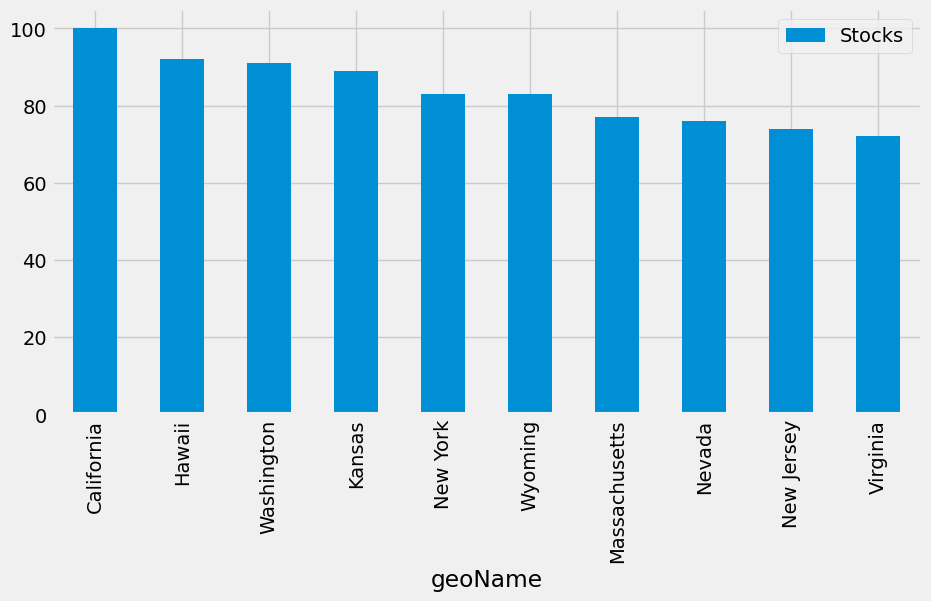

In [26]:
data.reset_index().plot(x='geoName', y='Stocks', kind='bar', figsize=(10,5))
plt.style.use('fivethirtyeight')
plt.show()

## Advanced Visualization of Regional Interest


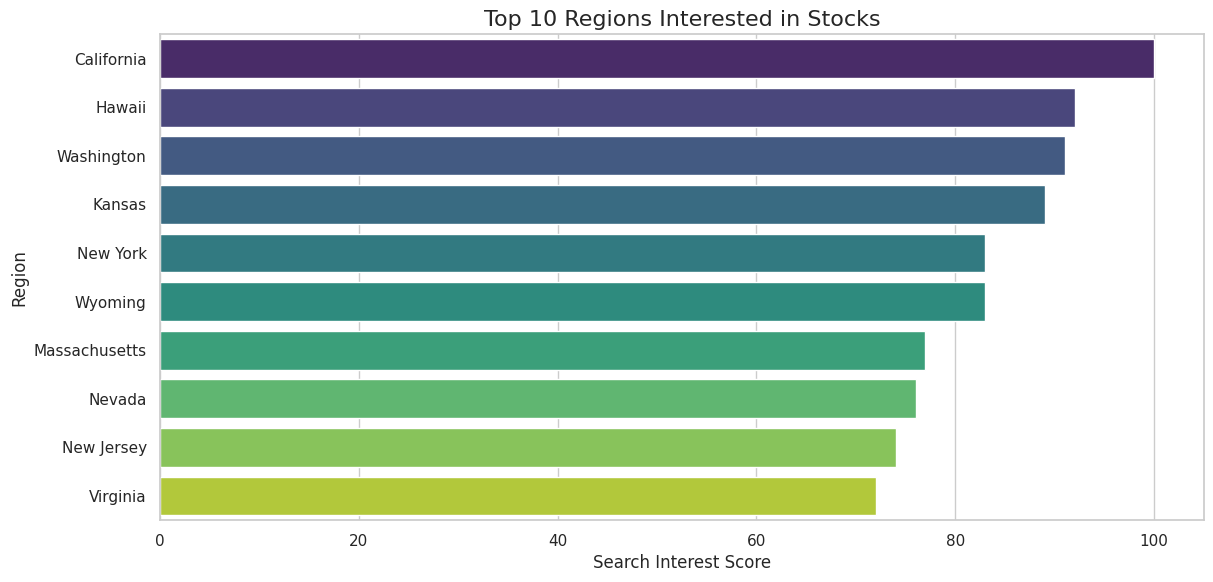

In [31]:
import seaborn as sns

# Reset index to treat 'geoName' as a column
regional_data = data.reset_index()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
# Assigning 'geoName' to hue to resolve the FutureWarning and enhance clarity
bar_plot = sns.barplot(x='Stocks', y='geoName', data=regional_data, hue='geoName', palette='viridis', legend=False)

plt.title('Top 10 Regions Interested in Stocks', fontsize=16)
plt.xlabel('Search Interest Score', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.show()

## 5. Hourly Trend Analysis
Extracts the hour from the timestamp to identify when during the day the search interest peaks.

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


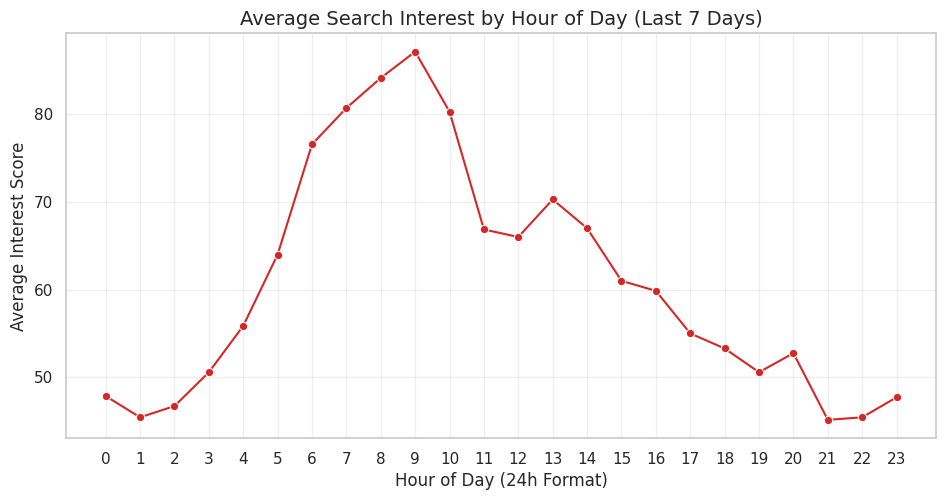

In [30]:
# Fetching 7-day hourly data
Trending_topics.build_payload(term_list, timeframe='now 7-d', geo='US')
hourly_data = Trending_topics.interest_over_time()

# Extract hour and aggregate
hourly_data['hour'] = hourly_data.index.hour
avg_hourly_interest = hourly_data.groupby('hour')['Stocks'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_hourly_interest, x='hour', y='Stocks', marker='o', color='tab:red')
plt.title('Average Search Interest by Hour of Day (Last 7 Days)', fontsize=14)
plt.xlabel('Hour of Day (24h Format)', fontsize=12)
plt.ylabel('Average Interest Score', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

## 6. Related Queries and Suggestions
Exploring what else users are searching for and getting keyword recommendations from Google.

In [27]:
# Searching for Related Queries
try:
  Trending_topics.build_payload(term_list)
  related_queries = Trending_topics.related_queries()
  related_queries.values()
except (KeyError, IndexError):
  print("No related queries found for 'Stocks")

In [28]:
# Keyword Suggestions
term='Stocks'
keywords = Trending_topics.suggestions(term)
df = pd.DataFrame(keywords)
df.drop(columns='mid')

,title,type
0,The Knight and the Moth,Novel by Rachel Gillig
1,The Simple Path to Wealth: Your Road Map to Fi...,Book by J. L. Collins
2,Ross Cameron,Trader
3,Stocks,Plant
4,American Society of Regional Anesthesia and Pa...,Company
